# **wordcount Project**

To complete this assignment, read and clean the input, then count the frequencies of each word. Remember that the data science process involves some pre-processing, then consists of some analysis itself.

Optionally, you can also filter out common words (“the”, “this”, “and”, etc.) by excluding words which appear in the stopwords file.

Overall, your approach will be:

- Create a data structure to store the words and the number of occurrences of the word.

- Read in each word from the file, making it lower case and removing punctuation. (Optionally, skip common words).

      For each remaining word, add the word to the data structure or update your count for the word

- Extract the top ten most frequently occurring words from your data structure and print them, along with their frequencies.

### **Checking your solution**:

You will get different counts on words depending on what punctuation you remove, what stop words you use, etc. So don't worry too much about getting the exact count we have. But if you want to see what we found, here are two examples:

    Without using stop words and removing the punctuation (. , " “ ), the top 10 most common words should be:

    the : 8177
    and : 4984
    of : 4122
    to : 3536
    a : 2976
    in : 2612
    his : 1998
    it : 1879
    i : 1872
    that : 1861

    Using the stop words and removing the punctuation (. , " “ ), the top 10 most common words should be:

    said : 642
    mr : 616
    one : 420
    lorry : 313
    will : 290
    upon : 289
    little : 264
    man : 259
    defarge : 259
    time : 236

\*Feel free to add more words to your stopwords file if you wish to get to less common words. For example, "said" and "mr" could be considered common words.

Hints

1. Which Data Structure? If you aren't sure which data structure to use, remember that we discussed a data structure this week that gives us a key and a value at that key (dictionaries). This could be really useful here.

2. Stripping off Punctuation. The command "replace" on a string will replace one letter with another. For example:

   `word = word.replace(".","") # will remove any periods from the word.`

3. Sorting the data structure. If you used an unordered data structure like a dictionary, you might need get the values out of it (into a list) to sort it. You could also use "collections.Counter" to help with this step.


In [5]:
import os

print(os.getcwd()) # get current working directory
# File is manually downloaded into working directory so no need to use wget...

c:\Users\aiden\OneDrive - University of Toledo\Fall 2024 UT\Data Science I\Jupyter Notebook\Notebooks


**<h2 style="text-align:center;">Main Word Count Project</h2>**


In [6]:
# Download the word_cloud folder from the class data science files,
# the text of the United "States Constitution"

import os
import re # We can use Regex to remove some of the punctuation

filepath = 'C:/Users/aiden/OneDrive - University of Toledo/Fall 2024 UT/Data Science I/Jupyter Notebook/Text Files'


# Lets use a set to put the stopwords together, the set() doesnt allow duplicated characters further validating/cleaning the stopwords file
stopwords = set()

# Add error handling for finding the stopwords file
try:
	with open(os.path.join(filepath,'stopwords')) as f:
		for line in f.readlines():
			stopwords.add(line.strip().lower()) # remove leading and trailing blanks #.add(): put them into a set. Can also put into list using .append()
except FileNotFoundError:
	print(f"Error: File 'stopwords' not found in {filepath}.")
except Exception as e:
	print(f"An unknown error occurred: {e}")

# Create dictionary object
wordcount = {}

# Add error handling for finding the consitution text file
try:
	with open(os.path.join(filepath, 'constitution.txt')) as f:
		for line in f.readlines():
			# This replaces any character that is not a word character (\w) or whitespace (\s) with a space, effectively removing punctuation
			words = re.sub(r'[^\w\s]', '', line.lower()).split()
			for word in words:
				if word and word not in stopwords:
					# Update word count here
					if word in wordcount:
						wordcount[word] += 1
					else:
						wordcount[word] = 1
except FileNotFoundError:
	print(f"Error: File 'constitution.txt' not found in {filepath}.")
except Exception as e:
	print(f"An unknown error occurred: {e}")

# after building your wordcount, you can then sort it and return the first

# We can actually use the python sorted function with arguements to sort by freq and put in descending order
sorted_wordcount = sorted(wordcount.items(), key=lambda x: x[1], reverse=True)

# Print out 10 most common words using index slicing, this gives us the list object itself
print(sorted_wordcount[:10])


[('states', 79), ('united', 54), ('state', 48), ('president', 34), ('may', 33), ('congress', 29), ('house', 23), ('law', 23), ('section', 22), ('one', 19)]


**<h2 style="text-align:center;"> Other Renditions using Data Science libraries</h2>**


### **USING REGEX AND COUNTER LIBRARY**


In [7]:
# Use of "Counter" library from "collections"
from collections import Counter
import re

filepath = 'C:/Users/aiden/OneDrive - University of Toledo/Fall 2024 UT/Data Science I/Jupyter Notebook/Text Files'

stopwords = set()

# Load stopwords into a set
try:
	with open(os.path.join(filepath,'stopwords')) as f:
		for line in f.readlines():
			stopwords.add(line.strip().lower()) # remove leading and trailing blanks #.add(): put them into a set. Can also put into list using .append()
except FileNotFoundError:
	print(f"Error: File 'stopwords' not found in {filepath}.")
except Exception as e:
	print(f"An unknown error occurred: {e}")

# Process text with Counter
try:
	with open(os.path.join(filepath,'constitution.txt')) as f:
		text = re.sub(r'[^\w\s]', '', f.read().lower())
		words = [word for word in text.split() if word not in stopwords] # We can use list comprehension combined with if-else and for loops to create a list for "words"
except FileNotFoundError:
	print(f"Error: File 'constitution.txt' not found in {filepath}.")
except Exception as e:
	print(f"An unknown error occurred: {e}")

# We just use the counter library instead of manually counting each word and adding it to a dictionary!
wordcounts = Counter(words)
mostcommonwords = wordcounts.most_common(10)

print('10 Most Common Words in constitution.txt: \n')
for word, count in mostcommonwords:
	print(f'{word}: {count}')

10 Most Common Words in constitution.txt: 

states: 79
united: 54
state: 48
president: 34
may: 33
congress: 29
house: 23
law: 23
section: 22
one: 19


### **USING PANDAS, REGEX AND COUNTER LIBRARY**


In [8]:
import pandas as pd
from collections import Counter
import os
import re

filepath = 'C:/Users/aiden/OneDrive - University of Toledo/Fall 2024 UT/Data Science I/Jupyter Notebook/Text Files'

stopwords = set()

# Load stopwords into a set
try:
	with open(os.path.join(filepath,'stopwords')) as f:
		for line in f.readlines():
			stopwords.add(line.strip().lower()) # remove leading and trailing blanks #.add(): put them into a set. Can also put into list using .append()
except FileNotFoundError:
	print(f"Error: File 'stopwords' not found in {filepath}.")
except Exception as e:
	print(f"An unknown error occurred: {e}")

try:
	with open(os.path.join(filepath, 'constitution.txt')) as f:
		text = re.sub(r'[^\w\s]', '', f.read().lower())
		words = [word for word in text.split() if word not in stopwords] # Another example of list comprehension

		# Count word frequencies using Counter
		wordcounts = Counter(words)

		# Convert to DataFrame and sort by count, descending
		dataframe = pd.DataFrame(wordcounts.items(), columns=['Word', 'Count'])
		df = dataframe.sort_values(by='Count', ascending=False).reset_index(drop=True)

		# Display the top 10 most common words
		print(df[:10])
except FileNotFoundError:
	print(f"Error: File 'constitution.txt' not found in {filepath}.")
except Exception as e:
	print(f"An unknown error occurred: {e}")

        Word  Count
0     states     79
1     united     54
2      state     48
3  president     34
4        may     33
5   congress     29
6      house     23
7        law     23
8    section     22
9        one     19


### **USING MATPLOTLIB, PANDAS DATAFRAMES, COUNTER AND REGEX LIBRARY ALL TOGETHER**


       Words  Count
0     states     79
1     united     54
2      state     48
3  president     34
4        may     33
5   congress     29
6      house     23
7        law     23
8    section     22
9        one     19


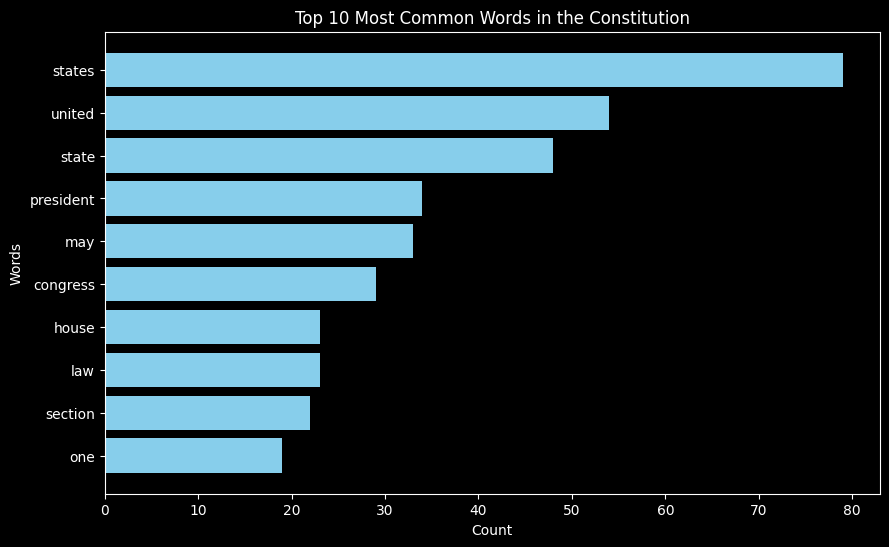

In [9]:
import pandas as pd
from collections import Counter
import os
import re
import matplotlib.pyplot as plt

filepath = 'C:/Users/aiden/OneDrive - University of Toledo/Fall 2024 UT/Data Science I/Jupyter Notebook/Text Files'

stopwords = set()

# Load stopwords into a set
try:
	with open(os.path.join(filepath, 'stopwords')) as f:
		for line in f:
			stopwords.add(line.strip().lower())
except FileNotFoundError:
	print(f"Error: File 'stopwords' not found in {filepath}.")
except Exception as e:
	print(f"An unknown error occurred: {e}")

# Process text and create DataFrame
try:
	with open(os.path.join(filepath, 'constitution.txt')) as f:
		text = re.sub(r'[^\w\s]', '', f.read().lower())
		words = [word for word in text.split() if word not in stopwords] # Another example of list comprehension

		# Count word frequencies using Counter
		wordcounts = Counter(words)

		# Convert to DataFrame and sort by count, descending
		dataframe = pd.DataFrame(wordcounts.items(), columns=['Words', 'Count'])
		df = dataframe.sort_values(by='Count', ascending=False).reset_index(drop=True)

		# Display the top 10 most common words
		top_df = df[:10]
		print(top_df)

		# Plotting the top 10 most common words as a horizontal bar chart
		plt.figure(figsize=(10, 6))
		plt.barh(top_df['Words'], top_df['Count'], color='skyblue')
		plt.xlabel("Count")
		plt.ylabel("Words")
		plt.title("Top 10 Most Common Words in the Constitution")
		plt.gca().invert_yaxis()  # Highest count at the top
		plt.show()
except FileNotFoundError:
	print(f"Error: File 'constitution.txt' not found in {filepath}.")
except Exception as e:
	print(f"An unknown error occurred: {e}")